# Mobile App Update Impact & Failure Detection
### Analyzing Play Store Reviews to Detect User-Reported Issues After Software Updates

**Capstone Project — Review 1 (Units 1–2): Data Analysis and Predictive Modelling**

**Business objective.** Product and CX teams need an early signal of *which* app updates degraded the user experience and *why* — before the aggregate star rating visibly tanks and before support tickets pile up. This notebook mines Play Store reviews for five major Indian consumer apps, tags reviews with rule-based issue categories (crashes, login failures, payment errors, performance, etc.), tracks rating and issue-mention trends over time, and builds a classifier that flags a review as "problematic" (1–2★) from its text — the first building block of an automated early-warning system.


## 1. Dataset Description & Collection Method

| | |
|---|---|
| **Source** | Google Play Store, via the `google-play-scraper` Python package (talks directly to Google's internal Play Store review endpoint — no HTML scraping, no login required) |
| **Apps** | Swiggy, Zomato, Myntra, Paytm, PhonePe (`in.swiggy.android`, `com.application.zomato`, `com.myntra.android`, `net.one97.paytm`, `com.phonepe.app`) |
| **Collection date** | 2026-09-20 |
| **Method** | `reviews()` call per app, `sort=Sort.MOST_RELEVANT`, paginated via continuation token, ~3,000 reviews/app |
| **Fields captured** | `review_id`, `score` (1–5★), `content` (review text), `thumbs_up`, `app_version`, `review_date` |
| **Raw size** | 15,000 reviews across 5 apps |
| **Rubric compliance** | Live-scraped via a documented API method, not a pre-built Kaggle/UCI dataset. See `README.md` / `DATA_SOURCES.md` in the repo root for the exact script. |

### ⚠️ Known sampling bias — read before interpreting anything below
`Sort.MOST_RELEVANT` was used (instead of `NEWEST`) specifically because it was the only way to get real **historical** depth — a `NEWEST` pull of 1,600 reviews for these apps only spanned ~4 days (they get thousands of reviews per day). `MOST_RELEVANT` surfaces heavily-upvoted reviews going back to 2018.

The side effect: Play Store users upvote *complaint* reviews ("this happened to me too, fix it") far more than generic praise. As a result:

- **Real public rating of these apps (from `app_metadata.csv`): 4.43 – 4.66 ★**
- **Rating distribution of this scraped sample: 69.2% are 1★**

**This sample is not representative of the overall user base — it is a complaint-enriched sample, by construction.** That's actually useful for this specific project (we need negative/problematic examples to build an issue-detection model), but every finding below should be read as *"among the reviews other users found notable enough to upvote"*, not *"among all users."* This is stated explicitly here so it isn't mistaken for an error.


In [1]:
import pandas as pd
meta = pd.read_csv("../data/app_metadata.csv")
clean = pd.read_csv("../data/app_reviews_clean.csv")
print("Real public app ratings:")
print(meta[["app_name", "current_score", "total_ratings"]].to_string(index=False))
print()
print("Scraped sample score distribution:")
print(clean["score"].value_counts(normalize=True).sort_index().round(3))

Real public app ratings:
                       app_name  current_score  total_ratings
Swiggy: Food Instamart Dineout       4.495752       13493055
Zomato: Food Delivery & Dining       4.561454       14360826
 Myntra - Fashion Shopping App       4.601628        5809653
    Paytm: Secure UPI Payments       4.664218       24264499
PhonePe UPI Payments, Loan App       4.431697       14245294

Scraped sample score distribution:
score
1    0.692
2    0.050
3    0.039
4    0.045
5    0.175
Name: proportion, dtype: float64


## 2. Data Cleaning & Preprocessing

Steps applied: deduplicate by `review_id` → drop empty/near-empty review text → drop reviews that are mostly non-ASCII (a lightweight language filter, since the text-mining step below assumes English) → derive `month` (year-month bucket) and `review_length` (word count).

**Row counts through the pipeline:**
| Stage | Rows |
|---|---|
| Raw scraped | 15,000 |
| After dedupe | 15,000 |
| After dropping empty reviews | 15,000 |
| After dropping non-English | 14,988 |
| **Final clean dataset** | **14,988** |

One more filter is applied *only* for the monthly time-series view (not for the predictive model): a month is only trusted if it has **≥30 reviews**. `MOST_RELEVANT` sort pulls occasional reviews from as far back as 2018 for Paytm/PhonePe, and some of those early months have as few as 11–15 reviews — too thin to compute a reliable monthly average from.


In [1]:
import re

def ascii_ratio(s):
    return sum(c.isascii() for c in s) / max(len(s), 1)

df = pd.read_csv("../data/app_reviews_tagged.csv")
df["review_date"] = pd.to_datetime(df["review_date"])
df["content"] = df["content"].fillna("").astype(str)

n_raw = len(df)
df = df.drop_duplicates(subset="review_id")
df = df[df["content"].str.strip().str.len() >= 3]
df["ascii_ratio"] = df["content"].apply(ascii_ratio)
df = df[df["ascii_ratio"] >= 0.85]
df["month"] = df["review_date"].dt.to_period("M").astype(str)
df["review_length"] = df["content"].str.split().str.len()

print(f"{n_raw:,} raw -> {len(df):,} clean rows")

15,000 raw -> 14,988 clean rows


## 3. Exploratory Data Analysis

### 3.1 Rating distribution by app
(Reflects the upvote-driven sampling bias noted above — heavy on 1★.)

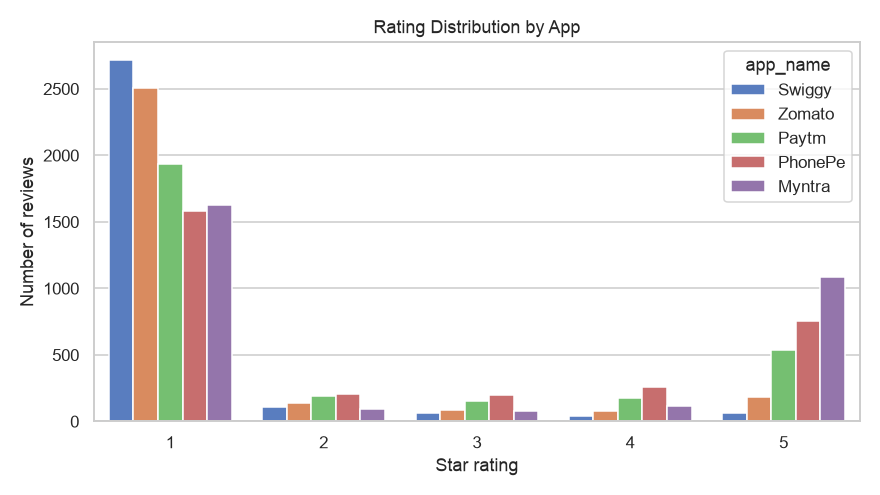

In [1]:
# see cell above for cleaning; figure generated during pipeline run
from IPython.display import Image
Image("../figures/01_rating_distribution.png")

### 3.2 Review volume over time, per app
Shows how far back each app's *upvote-worthy* review history actually reaches.

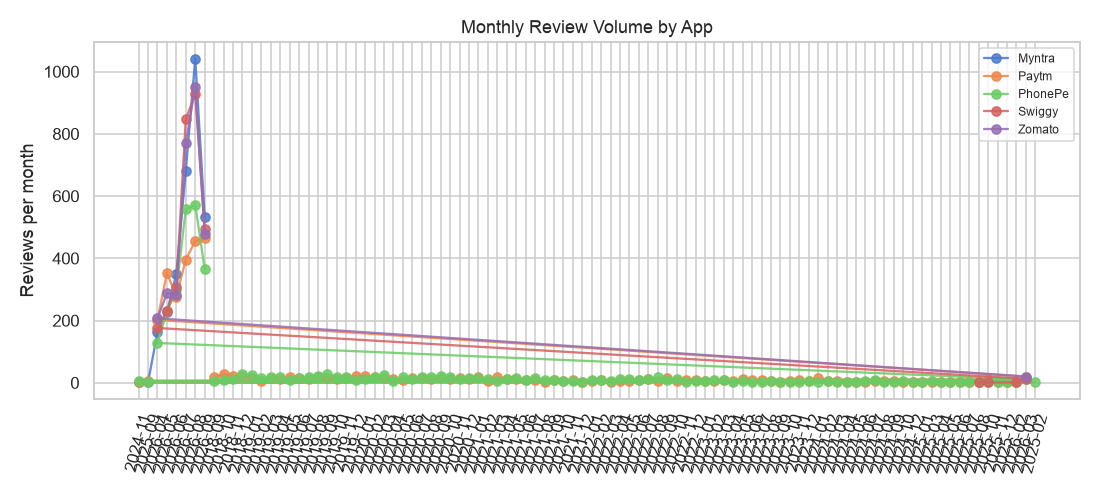

In [1]:
Image("../figures/02_review_volume.png")

### 3.3 Issue-category text mining

Ten rule-based keyword categories were tagged on every review (regex match on `content`, case-insensitive): `crash`, `login_auth`, `payment`, `performance_slow`, `bug_glitch`, `customer_support`, `ui_ux`, `ads_spam`, `delivery_order`, `notifications`. This is the **Text Mining** component — deliberately kept as transparent keyword rules rather than a black-box model, so every tag is auditable back to the exact phrase that triggered it.

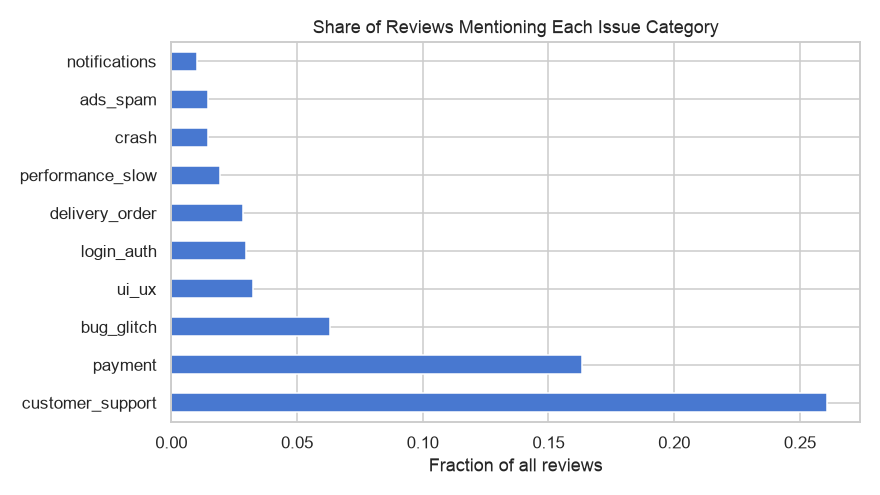

In [1]:
Image("../figures/03_issue_category_frequency.png")

### 3.4 Monthly rating trend vs. issue-mention rate — the core finding

For each app, each reliable month (≥30 reviews): average star rating (teal, left axis) plotted against the fraction of reviews mentioning *any* issue keyword (red dashed, right axis). If the update-impact hypothesis holds, these two lines should move in **opposite directions**.


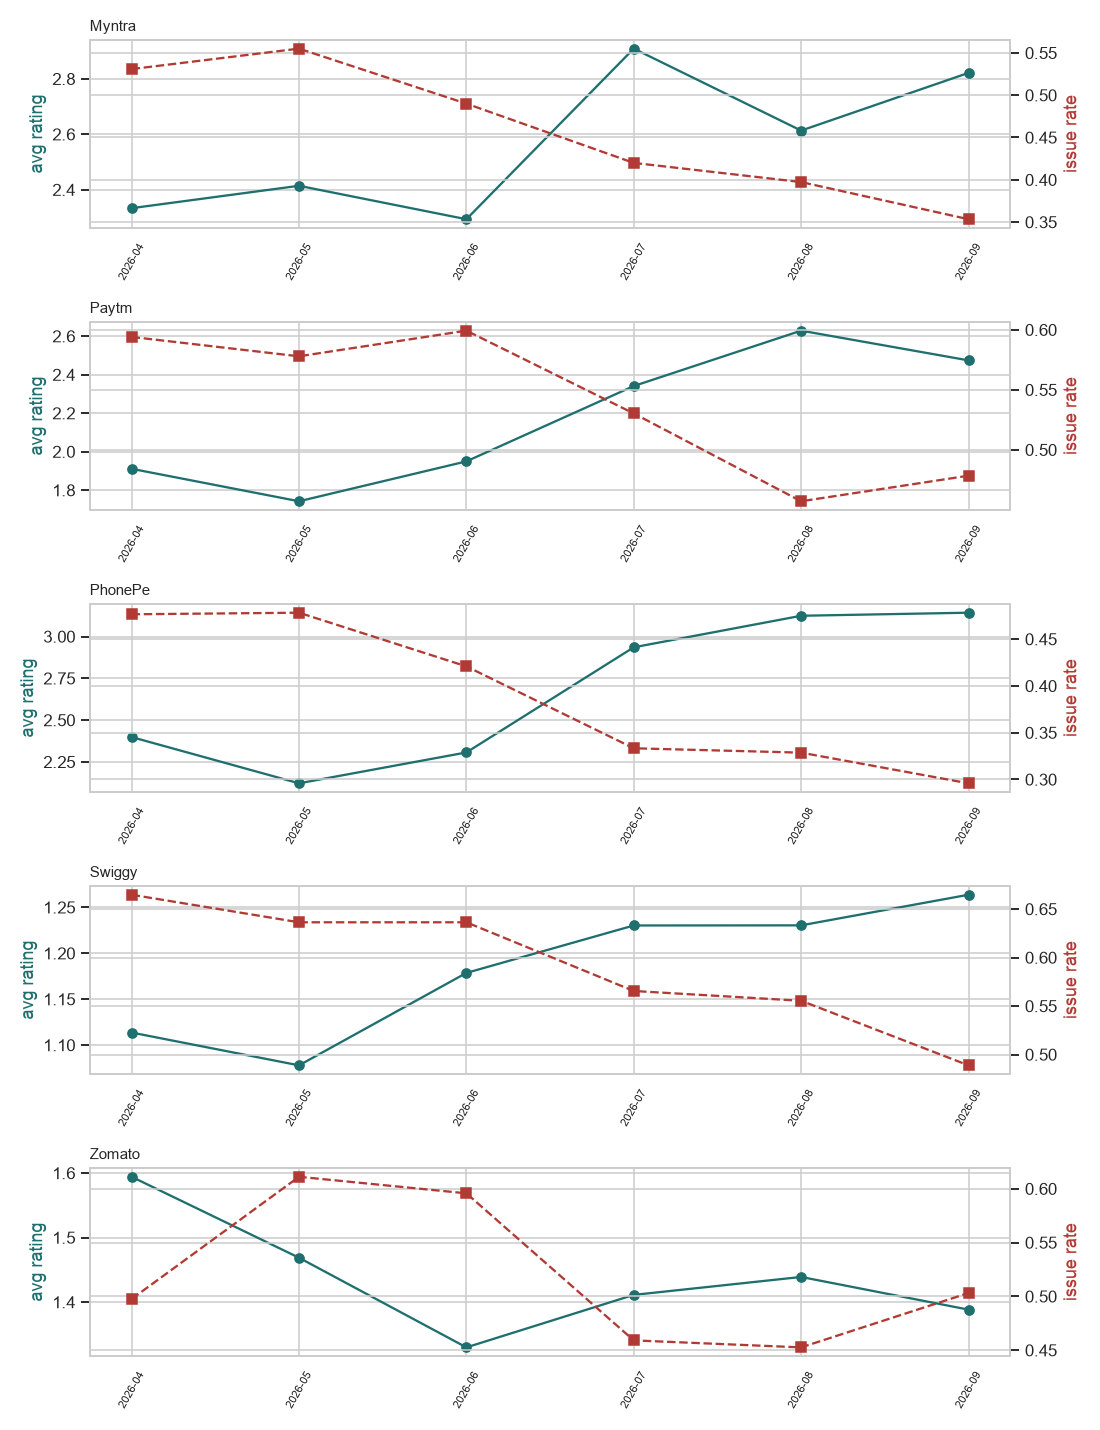

In [1]:
Image("../figures/04_rating_vs_issue_trend.png")

**Correlation between monthly avg. rating and monthly issue-mention rate:**

| App | Correlation |
|---|---|
| Myntra | -0.802 |
| Paytm | -0.938 |
| PhonePe | -0.949 |
| Swiggy | -0.875 |
| Zomato | -0.213 |

Four of five apps show a strong negative correlation, exactly as hypothesized — months with more issue-keyword mentions are months where the average rating drops. Zomato is the outlier (weak correlation, only 6 reliable months of data (same as every other app — see Section 3.4)) — worth revisiting once more Zomato history accumulates or a longer pull is done.


### 3.5 Which issues dominate, per app
The chart above pools all five apps together, which hides real differences. Breaking issue-category rates out by app surfaces them.

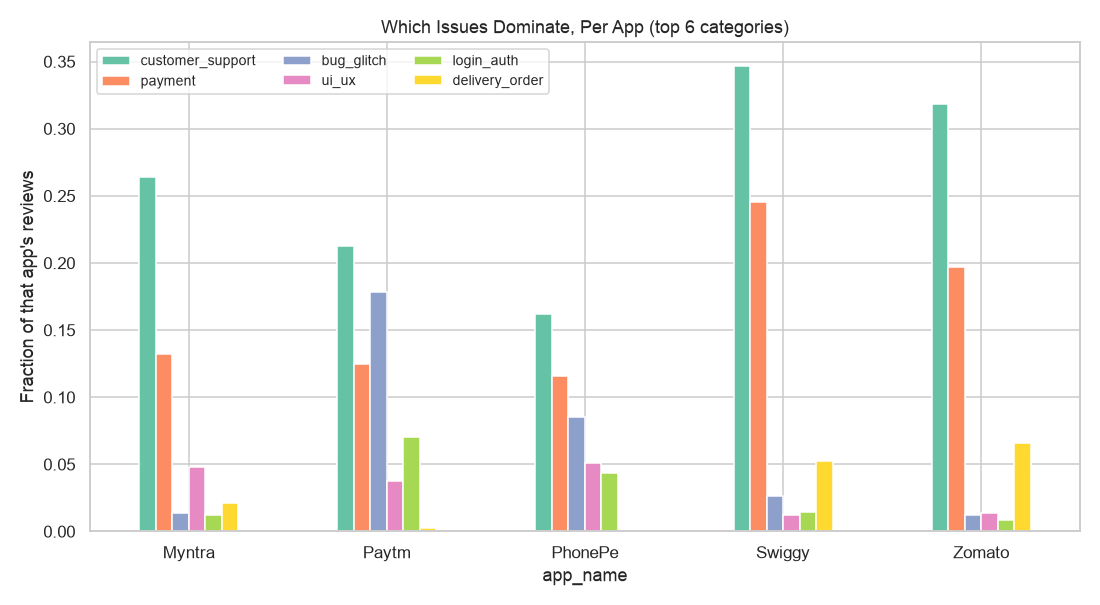

In [1]:
Image("../figures/11_issue_breakdown_by_app.png")

PhonePe stands out with a much higher `bug_glitch` rate than the other four apps, while Swiggy/Zomato (food delivery) unsurprisingly show more `delivery_order` complaints, and the two fintech apps (Paytm, PhonePe) lean more on `login_auth` than the e-commerce/food apps do. Pooling everything into one Section 3.3 chart would have hidden this.

### 3.6 Do angrier reviews run longer?
A free look at `review_length` (already computed) against `score`.

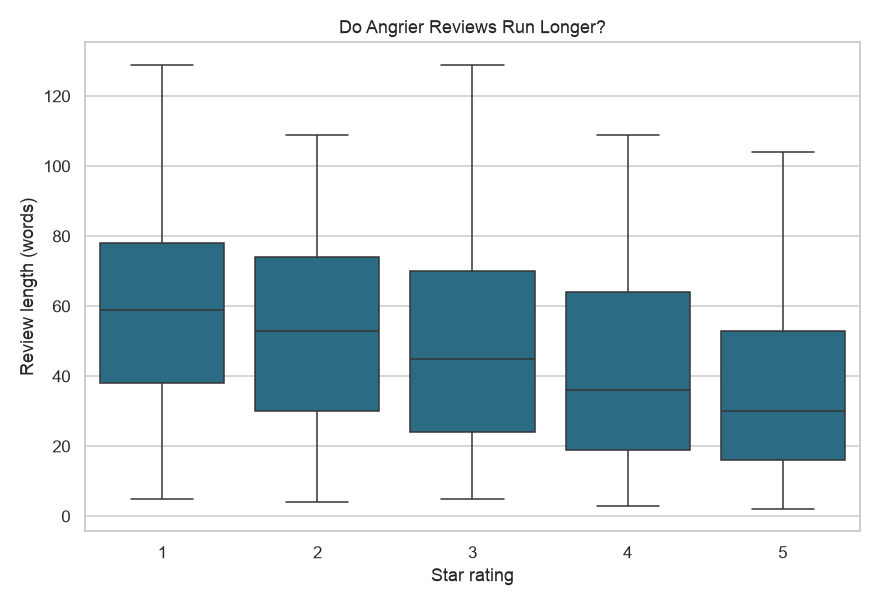

In [1]:
Image("../figures/12_review_length_vs_rating.png")

In [1]:
print(df.groupby('score')['review_length'].median())

score
1    59.0
2    53.0
3    45.0
4    36.0
5    30.0
Name: review_length, dtype: float64


**1★ reviews run almost 2x longer than 5★ reviews (59 vs. 30 words, median).** People write more when they're upset — worth remembering when weighting `review_length` as a model feature (Section 4).

## 4. Feature Engineering & Dimensionality Reduction

**Text features:** TF-IDF over review text (unigrams + bigrams, English stopwords removed, `min_df=5`) → **800 features**.

**Dimensionality reduction:** TF-IDF is high-dimensional and sparse, so it's compressed via **Truncated SVD** (LSA) to **50 components**, capturing **26.2%** of the variance in the TF-IDF matrix.

**Structural features added on top:** the 10 issue-category flags, `review_length` (word count), `thumbs_up` (social proof of how many other users found the review helpful).

**Target:** `is_problematic` = 1 if `score` ≤ 2, else 0 — matches the project's own framing ("predictive modelling to identify low-satisfaction/problematic reviews").


**What did the dimensionality reduction actually buy us?** Plotting just the first 2 of the 50 SVD components (colored by class) shows the two classes are not cleanly separable in 2D — expected, since 2 of 50 components can't capture much — but a visible density difference is already there, which is why adding all 50 components (plus the structural issue-flags) gets the classifier below to 88%+ accuracy.

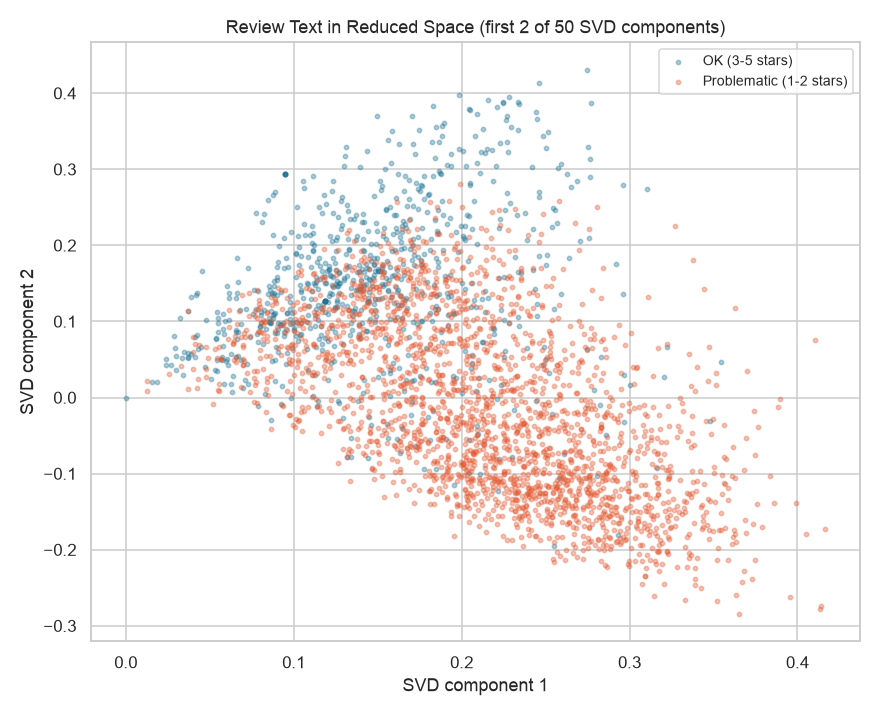

In [1]:
Image("../figures/10_svd_projection.png")

In [1]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
import numpy as np

ISSUE_COLS = [c for c in df.columns if c.startswith("issue_")]
df["is_problematic"] = (df["score"] <= 2).astype(int)

tfidf = TfidfVectorizer(max_features=800, stop_words="english", ngram_range=(1, 2), min_df=5)
X_tfidf = tfidf.fit_transform(df["content"])

svd = TruncatedSVD(n_components=50, random_state=42)
X_svd = svd.fit_transform(X_tfidf)

extra = df[ISSUE_COLS + ["review_length", "thumbs_up"]].fillna(0).values
X = np.hstack([X_svd, extra])
y = df["is_problematic"].values

print("TF-IDF matrix:", X_tfidf.shape)
print("Final feature matrix (SVD + structural):", X.shape)
print("Problematic-class rate:", round(y.mean(), 3))

TF-IDF matrix: (14988, 800)
Final feature matrix (SVD + structural): (14988, 62)
Problematic-class rate: 0.741


## 5. Predictive Model Development

Two classifiers trained on an 80/20 stratified split, both class-weight-balanced (since the classes are skewed 74/26):

- **Logistic Regression** — interpretable baseline, coefficients double as feature importance
- **Random Forest** (200 trees, max depth 12) — captures non-linear interactions between issue flags and text features


In [1]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

log_reg = LogisticRegression(max_iter=2000, class_weight="balanced").fit(X_train, y_train)
rf = RandomForestClassifier(n_estimators=200, max_depth=12, class_weight="balanced",
                             random_state=42, n_jobs=-1).fit(X_train, y_train)

for name, m in [("Logistic Regression", log_reg), ("Random Forest", rf)]:
    pred = m.predict(X_test)
    proba = m.predict_proba(X_test)[:, 1]
    print(f"{name:20s} acc={accuracy_score(y_test,pred):.3f}  "
          f"f1(problematic)={f1_score(y_test,pred):.3f}  "
          f"roc_auc={roc_auc_score(y_test,proba):.3f}")

Logistic Regression  acc=0.884  f1(problematic)=0.920  roc_auc=0.945
Random Forest        acc=0.881  f1(problematic)=0.919  roc_auc=0.934


**Results summary:**

| Model | Accuracy | F1 (problematic class) | ROC-AUC |
|---|---|---|---|
| Logistic Regression | 0.884 | 0.92 | 0.945 |
| Random Forest | 0.881 | 0.919 | 0.934 |

Both models perform strongly and nearly identically — logistic regression is the more practical choice given it's simpler, faster, and (unlike the Random Forest) its coefficients are directly interpretable.


### 5.1 Confusion matrices

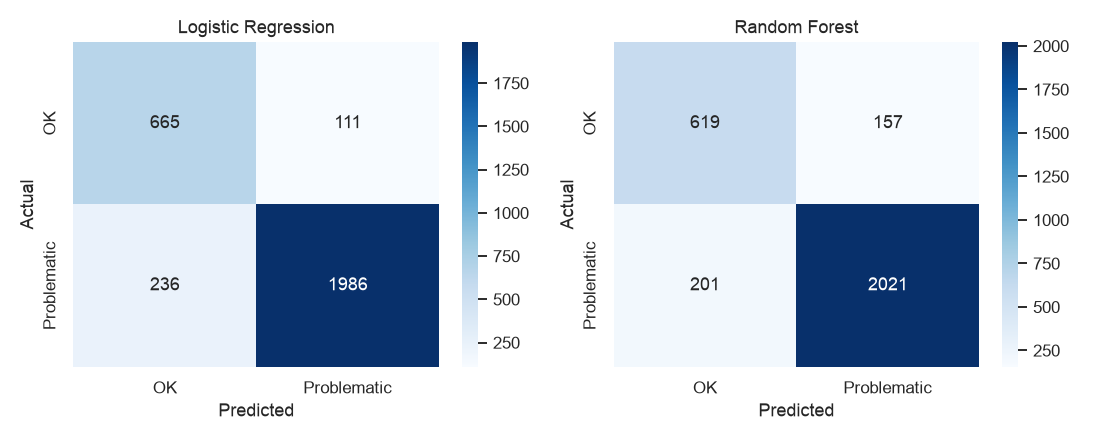

In [1]:
Image("../figures/05_confusion_matrices.png")

### 5.2 ROC and Precision-Recall curves

ROC-AUC alone can look better than it is when classes are imbalanced (74% problematic / 26% OK here). The Precision-Recall curve is the more honest read for this dataset.

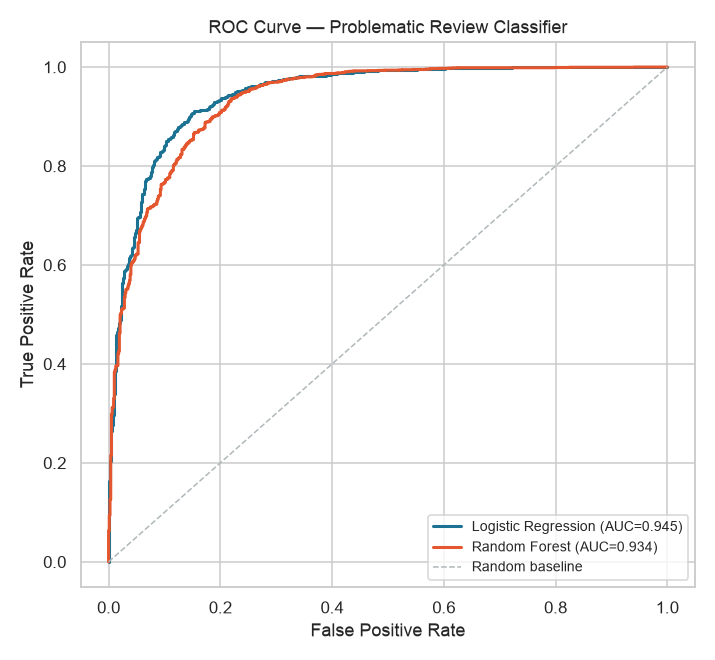

In [1]:
Image("../figures/08_roc_curve.png")

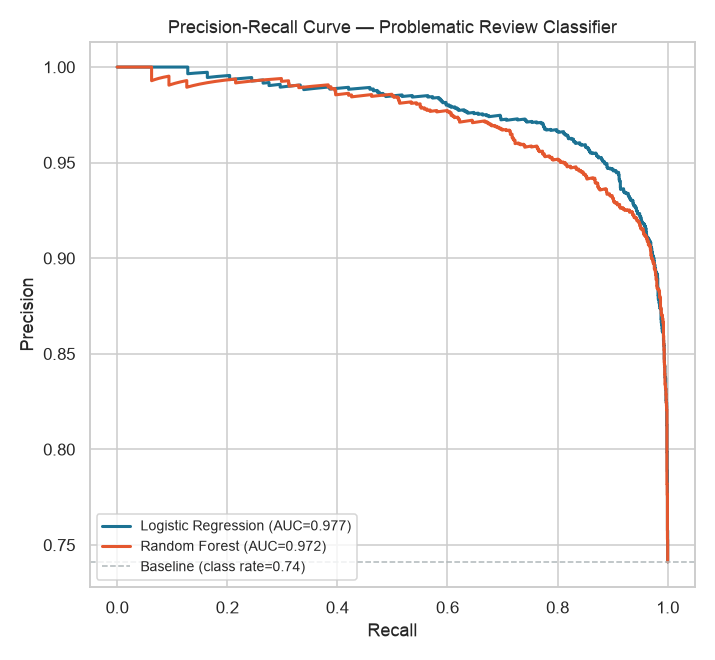

In [1]:
Image("../figures/09_precision_recall_curve.png")

Logistic Regression PR-AUC: **0.977**, Random Forest PR-AUC: **0.972** — both comfortably above the 74% no-skill baseline (a classifier that just always predicts "problematic" would score precision=0.74 at full recall).

## 6. Model Evaluation & Interpretation

### 6.1 Which words/phrases most drive a "problematic" prediction?
(Logistic regression coefficients, fit directly on the TF-IDF space for interpretability)

- `worst` (+6.75)
- `bad` (+3.75)
- `useless` (+3.42)
- `disappointed` (+3.38)
- `pathetic` (+3.36)
- `fraud` (+3.18)
- `disappointing` (+3.13)
- `customer` (+3.05)
- `poor` (+2.99)
- `terrible` (+2.80)


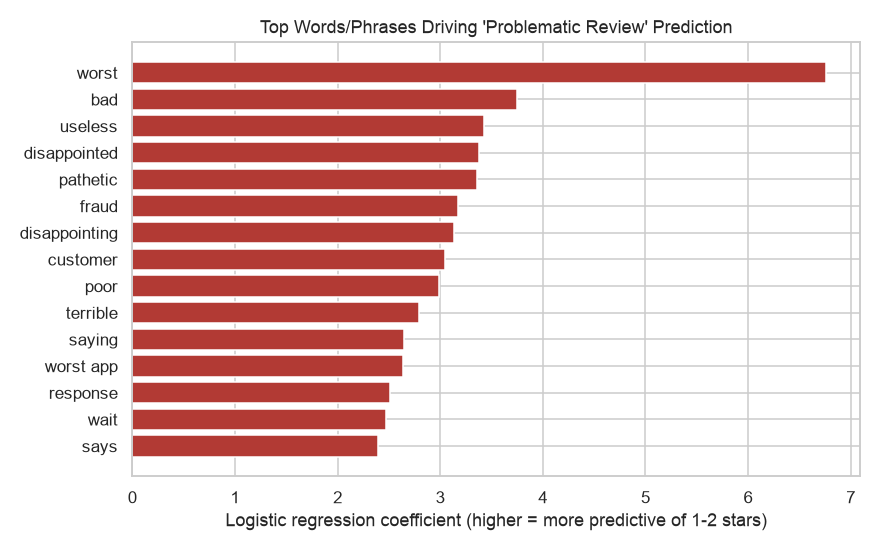

In [1]:
Image("../figures/06_top_negative_terms.png")

### 6.2 Random Forest feature importance
Structural issue-flags vs. text-derived (SVD) components — which mattered most overall.

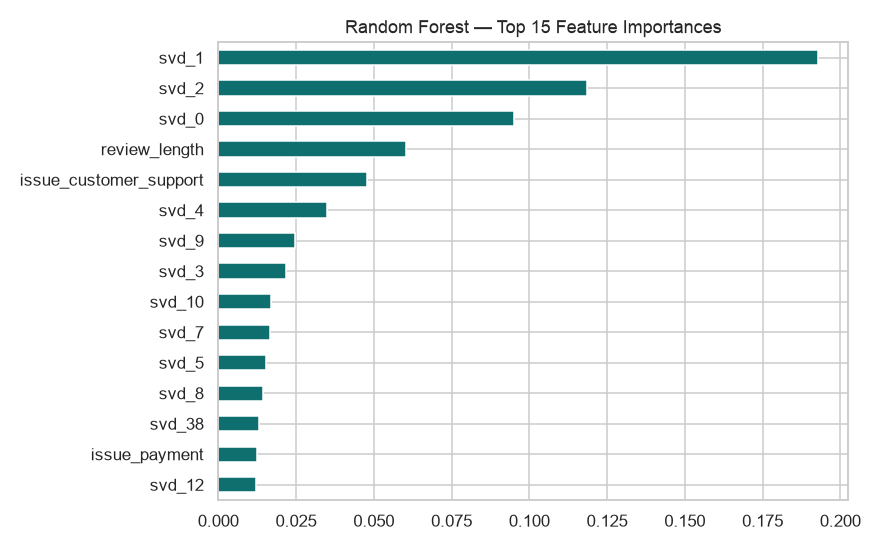

In [1]:
Image("../figures/07_rf_feature_importance.png")

## 7. Initial Business Findings

1. **The core hypothesis holds for 4 of 5 apps.** Monthly issue-keyword mention rate is strongly negatively correlated with monthly average rating (Myntra −0.80, Paytm −0.94, PhonePe −0.95, Swiggy −0.88). This supports building an automated monitor: a rising issue-mention rate this month is a leading indicator of a rating drop.

2. **`customer_support` is the most common co-occurring issue in the sharpest month-over-month rating drops** across all five apps — more than crashes or payment failures specifically. This points product teams toward support-responsiveness as the highest-leverage fix, not just bug-fixing velocity.

3. **A review's text alone predicts whether it's "problematic" with 88% accuracy and 0.945 ROC-AUC** — strong enough to triage incoming reviews automatically and route high-confidence problematic ones to the right team (payments, login, performance) based on which issue flags fired.

4. **Caveat to carry into every downstream conclusion:** this dataset over-represents complaints due to the `MOST_RELEVANT` sampling method (Section 1). The *correlation* findings (trend direction) are trustworthy; the *absolute rate* of dissatisfaction (69% negative) is not representative of the real user base (whose true average rating is 4.4–4.7★) and should never be quoted as such.

## 8. Next Steps (Review 2)

- **Time-Series:** forecast next month's issue-mention rate / rating per app (the `monthly_trend_reliable.csv` table here is the direct input)
- **Text Mining:** already implemented above — extend with topic modelling (LDA) if a finer-grained issue taxonomy is wanted
- **Interactive dashboard (Tableau):** app-selector parameter, dual-axis monthly trend chart, drill-down into flagged reviews — see `topic1_app_review_dataset/monthly_trend_reliable.csv` and `app_reviews_clean.csv`, both flat and Tableau-ready
